Raport z analizy i modelowania zbioru danych "Airline Passenger Satisfaction"

Wioletta Zdrodowska, 17.01.2026 r.

**1. Wstęp**

Motywacją do wybrania  zbioru "Airline Passenger Satisfaction" była chęć zrozumienia, które elementy podróży samolotem są kluczowe w finalnej ocenie satysfakcji pasażera.

Celem utworzenia raportu jest przeprowadzenie analizy wpływu czynników na satysfakcję pasażerów lini lotniczych, oraz zbudowanie modelu predykcyjnego dla zmiennej objaśnianej - poziomu satysfakcji.

**2. Opis danych**

Zbiór danych "Airline Passenger Satisfaction" pochodzi z platformy Kaggle. 
(https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)

Dane podzielone są na dwa podzbiory:<br>

- zbiór treningowy (train.csv), na nim przeprowadzana będzie analiza, czyszczenie danych, inżynierii cech oraz trenowania modeli
    
- zbiór testowy (test.csv), wykorzystany będzie wyłączenie do końcowej ewaluacji skuteczności zbudowanych modeli

W dokumentacji datasetu na platformie Kaggle mamy informację o następującyh zmiennych:<br>

**Zmienne demograficzne i opisujące pasażera**<br>
Gender: płeć pasażera (Female, Male)<br>
Customer Type: typ klienta (Loyal customer, disloyal customer)<br>
Age: wiek pasażera<br>

**Zmienne opisujące podróż**<br>
Type of Travel: cel podróży (Personal Travel, Business Travel)<br>
Class: klasa podróży (Business, Eco, Eco Plus)<br>
Flight distance: długość lotu<br>

**Zmienne opisujące jakość usług**<br>
Oceny wyrażone są w skali od 1 do 5<br>
Inflight wifi service: poziom satysfakcji z dostępu do Wi-Fi na pokładzie (ocena 0 - brak usługi)<br>
Departure/Arrival time convenient: ocena dogodności godzin odlotu i przylotu<br>
Ease of Online booking: ocena latwości dokonania rezerwacji online<br>
Gate location: ocena lokalizacji bramki<br>
Food and drink: ocena jakości posiłków i napojów<br>
Online boarding: ocena procesu boardingu online<br>
Seat comfort: ocena komfortu siedzenia<br>
Inflight entertainment: ocena rozrywki pokładowej<br>
On-board service: ocena obsługi na pokładzie<br>
Leg room service: ocena przestrzeni na nogi<br>
Baggage handling: ocena obsługi bagażu<br>
Check-in service: ocena procesu odprawy<br>
Inflight service: ogólna ocena obsługi podczas lotu<br>
Cleanliness: ocena czystości na pokładzie<br>

Departure Delay in Minutes: liczba minut opóźnienia odlotu<br>
Arrival Delay in Minutes: liczba minut opóźnienia przylotu<br>

**Zmienna docelowa**<br>
Satisfaction: poziom satysfakcji pasazera(Satisfaction, neutral or dissatisfaction)

**Import bibliotek**

In [6]:
#Podstawowe biblioteki
import numpy as np
import pandas as pd

#Biblioteki do wizualizacji danych
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing i pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Modele
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Ewaluacja
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use("seaborn-v0_8")

**Wczytywanie danych**

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

#Sprawdzenie wymiarów zbiorów
print("Zbiór treningowy:", train_df.shape)
print("Zbiór testowy:", test_df.shape)

Zbiór treningowy: (103904, 25)
Zbiór testowy: (25976, 25)


Dane zostały podzielone na zbiory w proporcji 80/20. Dzięki temu możliwe jest pominięcie etapu ręcznego podziału danych na zbiory treningowy i testowy.

In [11]:
pd.concat(
    {"Train": train_df.head(), "Test": test_df.head()}
)

Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
Train 0           0   70172    Male     Loyal Customer   13  Personal Travel   
      1           1    5047    Male  disloyal Customer   25  Business travel   
      2           2  110028  Female     Loyal Customer   26  Business travel   
      3           3   24026  Female     Loyal Customer   25  Business travel   
      4           4  119299    Male     Loyal Customer   61  Business travel   
Test  0           0   19556  Female     Loyal Customer   52  Business travel   
      1           1   90035  Female     Loyal Customer   36  Business travel   
      2           2   12360    Male  disloyal Customer   20  Business travel   
      3           3   77959    Male     Loyal Customer   44  Business travel   
      4           4   36875  Female     Loyal Customer   49  Business travel   

            Class  Flight Distance  Inflight wifi service  \
Train 0  Eco Plus              460                      3   
      1  Business              235                      3   
      2  Business             1142                      2   
      3  Business              562                      2   
      4  Business              214                      3   
Test  0       Eco              160                      5   
      1  Business             2863                      1   
      2       Eco              192                      2   
      3  Business             3377                      0   
      4       Eco             1182                      2   

         Departure/Arrival time convenient  ...  Inflight entertainment  \
Train 0                                  4  ...                       5   
      1                                  2  ...                       1   
      2                                  2  ...                       5   
      3                                  5  ...                       2   
      4                                  3  ...                       3   
Test  0                                  4  ...                       5   
      1                                  1  ...                       4   
      2                                  0  ...                       2   
      3                                  0  ...                       1   
      4                                  3  ...                       2   

         On-board service  Leg room service  Baggage handling  \
Train 0                 4                 3                 4   
      1                 1                 5                 3   
      2                 4                 3                 4   
      3                 2                 5                 3   
      4                 3                 4                 4   
Test  0                 5                 5                 5   
      1                 4                 4                 4   
      2                 4                 1                 3   
      3                 1                 1                 1   
      4                 2                 2                 2   

         Checkin service  Inflight service  Cleanliness  \
Train 0                4                 5            5   
      1                1                 4            1   
      2                4                 4            5   
      3                1                 4            2   
      4                3                 3            3   
Test  0                2                 5            5   
      1                3                 4            5   
      2                2                 2            2   
      3                3                 1            4   
      4                4                 2            4   

         Departure Delay in Minutes  Arrival Delay in Minutes  \
Train 0                          25                      18.0   
      1                           1                       6.0   
      2                           0                       0.0   
    

Zajrzenie do pierwszych pięciu obserwacji pozwaliło nam na wstępne zapoznanie się ze strukturą danych. Zbiór posiada zmienne zarówno numeryczne, jak i kategoryczne. Widoczna jest również kolumna "Unnamed: 0" która w dalszym etapie zostanie usunięta, ponieważ stanowi ona jedynie zduplikowaną informację o numerze obserwacji i nie wnosi wartości merytorycznej do analizy. Dodatkowo podgląd zbioru testowego umożliwił potwierdzenie spójności struktury obu podzbiorów danych.

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

Większość zmiennych w zbiorze danych ma charakter numeryczny. W zbiorze braki danych występują wyłącznie w kolumnie "Arrival Delay in Minutes".

In [11]:
train_df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Analiza statystyk opisowych wskazuje, że zmienne opisujące jakośc usług (m.in. Inflight wifi service, Departure/Arrival time convenient, Ease of Online booking) przyjmują wartości w skali od 1 do 5, co oznacza, że mają one charakter zmiennych kategorycznych porządkowych.

Zmienna Flight Distance wykazuje dużą zmienność, co wskazuje na obecność lotów zarówno krótkodystansowych jak i długodystansowych. 

Zmienne opisujące opóźnienia Departure Delay in Minutes oraz Arrival Delay in Minutes wykazują asymetrię prawostronną, co może sugerować występowanie obserwacji odstającyh (outlinerów), które zostaną bliżej przeanalizowane na etapie czyszczenia danych.

**3. Analiza eksploracyjna danych (EDA)**<br>
Pierwszym zasadniczym krokiem EDA jest zbadanie rozkładu zmiennej docelowej.

In [15]:
train_df["satisfaction"].value_counts(normalize=True)*100

satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64

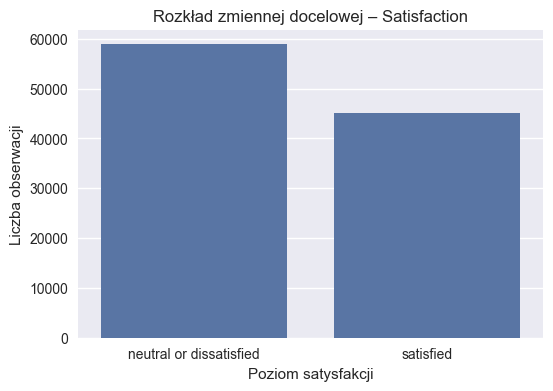

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="satisfaction")
plt.title("Rozkład zmiennej docelowej – Satisfaction")
plt.xlabel("Poziom satysfakcji")
plt.ylabel("Liczba obserwacji")
plt.show()

Rozkład zmiennej "satisfaction" nie wykazuje skrajnej nierównowagi klas, co umożliwia dalsze modelowanie bez konieczności równoważenia danych.

Kolejnym etapem analizy eksploracyjnej jest ocena wpływu wybranych zmiennych kategorycznych na pozziom satysfakcji pasażerów.

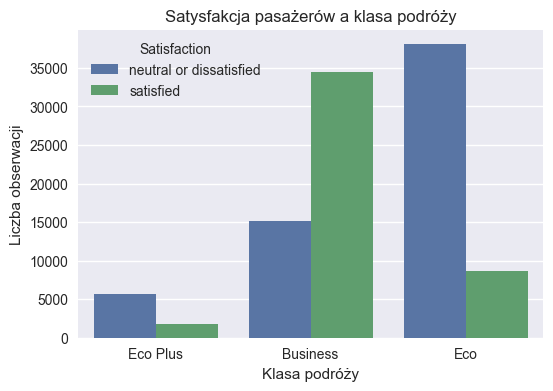

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Class", hue="satisfaction")
plt.title("Satysfakcja pasażerów a klasa podróży")
plt.xlabel("Klasa podróży")
plt.ylabel("Liczba obserwacji")
plt.legend(title="Satisfaction")
plt.show()

Widoczne są różnice w rozkładzie satysfakcji pomiędzy klasami podróży, może więc stanowić istotna cechę w procesie modelowania.

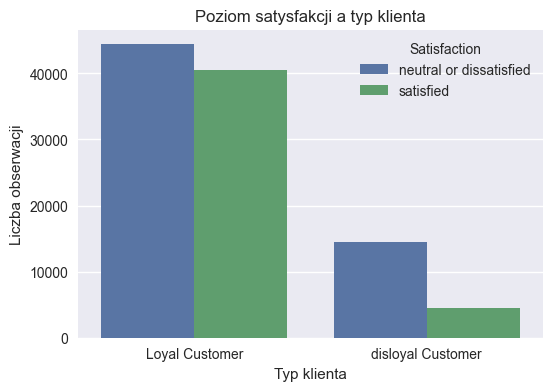

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Customer Type", hue="satisfaction")
plt.title("Poziom satysfakcji a typ klienta")
plt.xlabel("Typ klienta")
plt.ylabel("Liczba obserwacji")
plt.legend(title="Satisfaction")
plt.show()

W grupie klientów lojalnych rozkład jest względnie zrównoważony - liczba pasażerów zadowolonych jest porównywalna z liczbą pasażerów neturalnych lub niezadowolonych. Natomiast w przypadku klientów nielojalnych wyraźnie dominuje udział klientów neutralnych bądź niezadowolonych. Warto jednak zwrócić uwagę na nierówną liczebnośc aktegorii, jednak nie wyklucza to wykorzystania tej zmiennej przy modelowaniu.

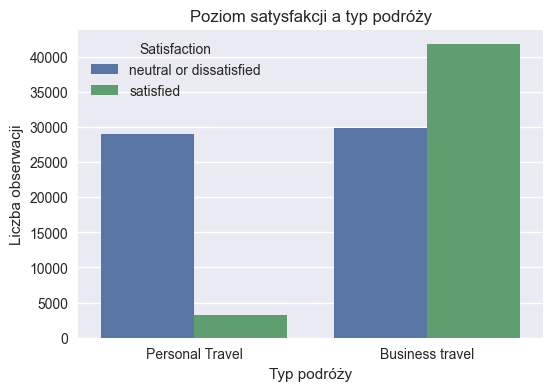

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Type of Travel", hue="satisfaction")
plt.title("Poziom satysfakcji a typ podróży")
plt.xlabel("Typ podróży")
plt.ylabel("Liczba obserwacji")
plt.legend(title="Satisfaction")
plt.show()

Analiza zmiennej typ podróży, a poziomem satysfakcji wykazała wyraźne różnice pomiędzy podrówami prywatnymi a słuzbowymi. Obserwowana jest silna zależność ze zmienną docelową zatem zmienna "type of travel" może stanowić istotną cechę w procesie modelowania.

Uzyskane wyniki z analizy zmiennych kategorycznych sugerują, że zmienne te niosą wartościową informację predykcyjne i zostaną uwzględnione w dalszych etapach modelowania.

Kolejnym etapem analizy eksploracyjnej jest ocena zależności pomiędzy zmienną docelową a ocenami jakości (w skali 1-5) poszczególnych elementów usług. Pozwoli to ocenić użyteczność tych zmiennych w etapie modelowania. 

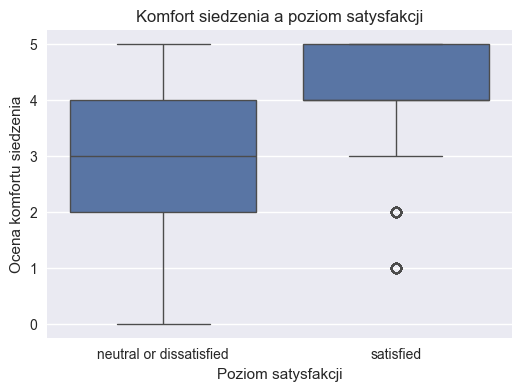

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train_df, x="satisfaction", y="Seat comfort")
plt.title("Komfort siedzenia a poziom satysfakcji")
plt.xlabel("Poziom satysfakcji")
plt.ylabel("Ocena komfortu siedzenia")
plt.show()